# Raw-Space Comparison: 4 Methods Without Normalization

Pearson and Cosine are scale-invariant *by definition* — no point running them on raw data.

DTW, Fréchet, MSE, and sMAPE are not inherently scale-invariant. They only *behave* that way in the Apr 9 pipeline because every gene gets normalized to (0, 1] before they see it. This notebook recomputes them on **unnormalized LT data** to see what their genuine picks look like when magnitude information is preserved.

Expectation: DTW, Fréchet, and MSE on raw should all collapse toward picks similar to raw MAE (since they're all magnitude-aware distance metrics). sMAPE is structurally relative (divides by sum of absolute values), so it may behave differently.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pickle, os

%matplotlib inline

# Load constraint patterns (from April 9 results pickle)
results = pickle.load(open('../Week of April 9th/metrics_results.pkl', 'rb'))
constraint_patternsLT = results['constraint_patternsLT']

# Load LT gene expression data (unnormalized)
x = [0, 3, 6, 9]
gene_dataLT = {}
for cluster_name in constraint_patternsLT:
    df = pd.read_csv(f'../analysis data/gene_countsLT/{cluster_name}_annotated.csv', index_col=0)
    df.columns = x
    gene_dataLT[cluster_name] = df

cluster_names = list(constraint_patternsLT.keys())
os.makedirs('plots', exist_ok=True)
print(f'Clusters: {cluster_names}')
print(f'Genes per cluster: {gene_dataLT[cluster_names[0]].shape[0]}')

Clusters: ['clusterOneLT', 'clusterTwoLT', 'clusterThreeLT', 'clusterFourLT']
Genes per cluster: 17856


In [2]:
# Simple implementations (4 timepoints → O(16) per pair, no libraries needed)

def dtw_distance(s, t):
    n, m = len(s), len(t)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            d = abs(s[i-1] - t[j-1])
            D[i, j] = d + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

def frechet_distance(s, t):
    n, m = len(s), len(t)
    ca = np.full((n, m), -1.0)
    # iterative fill
    for i in range(n):
        for j in range(m):
            d = abs(s[i] - t[j])
            if i == 0 and j == 0:
                ca[i, j] = d
            elif i > 0 and j == 0:
                ca[i, j] = max(ca[i-1, 0], d)
            elif i == 0 and j > 0:
                ca[i, j] = max(ca[0, j-1], d)
            else:
                ca[i, j] = max(min(ca[i-1, j], ca[i-1, j-1], ca[i, j-1]), d)
    return ca[n-1, m-1]

def mse(s, t):
    return float(np.mean((np.asarray(s) - np.asarray(t)) ** 2))

def smape(s, t):
    s, t = np.asarray(s, dtype=float), np.asarray(t, dtype=float)
    denom = np.abs(s) + np.abs(t)
    # When both are zero, per-timepoint contribution is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        term = np.where(denom > 0, 2 * np.abs(s - t) / denom, 0.0)
    return float(np.mean(term))

# Sanity check
p = np.array([0.04, 0.0, 0.037, 0.035])
print(f'DTW(p, p)     = {dtw_distance(p, p):.4f}  (should be 0)')
print(f'Frechet(p, p) = {frechet_distance(p, p):.4f}  (should be 0)')
print(f'MSE(p, p)     = {mse(p, p):.4f}  (should be 0)')
print(f'sMAPE(p, p)   = {smape(p, p):.4f}  (should be 0)')

DTW(p, p)     = 0.0000  (should be 0)
Frechet(p, p) = 0.0000  (should be 0)
MSE(p, p)     = 0.0000  (should be 0)
sMAPE(p, p)   = 0.0000  (should be 0)


In [3]:
# Rank every gene in every cluster by each metric, on raw LT data

raw_rankings = {'DTW': {}, 'Frechet': {}, 'MSE': {}, 'sMAPE': {}}

for cluster_name in cluster_names:
    pattern = np.array(constraint_patternsLT[cluster_name]['constraint'], dtype=float)
    gene_df = gene_dataLT[cluster_name]
    mat = gene_df.values  # (n_genes, 4)

    # Vectorize where possible; DTW and Fréchet need a loop (still fast at n_t=4)
    dtw_scores    = np.array([dtw_distance(row, pattern) for row in mat])
    frechet_scores = np.array([frechet_distance(row, pattern) for row in mat])
    mse_scores    = np.mean((mat - pattern) ** 2, axis=1)
    # sMAPE vectorized
    denom = np.abs(mat) + np.abs(pattern)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_t = np.where(denom > 0, 2 * np.abs(mat - pattern) / denom, 0.0)
    smape_scores = per_t.mean(axis=1)

    idx = gene_df.index
    raw_rankings['DTW'][cluster_name]     = pd.Series(dtw_scores, index=idx)
    raw_rankings['Frechet'][cluster_name] = pd.Series(frechet_scores, index=idx)
    raw_rankings['MSE'][cluster_name]     = pd.Series(mse_scores, index=idx)
    raw_rankings['sMAPE'][cluster_name]   = pd.Series(smape_scores, index=idx)

    short = cluster_name.replace('LT', '')
    print(f'{short}: computed all 4 metrics on {len(idx):,} genes')

clusterOne: computed all 4 metrics on 17,856 genes


clusterTwo: computed all 4 metrics on 17,856 genes


clusterThree: computed all 4 metrics on 17,856 genes


clusterFour: computed all 4 metrics on 17,856 genes


## Per-method view — top 20 genes per cluster

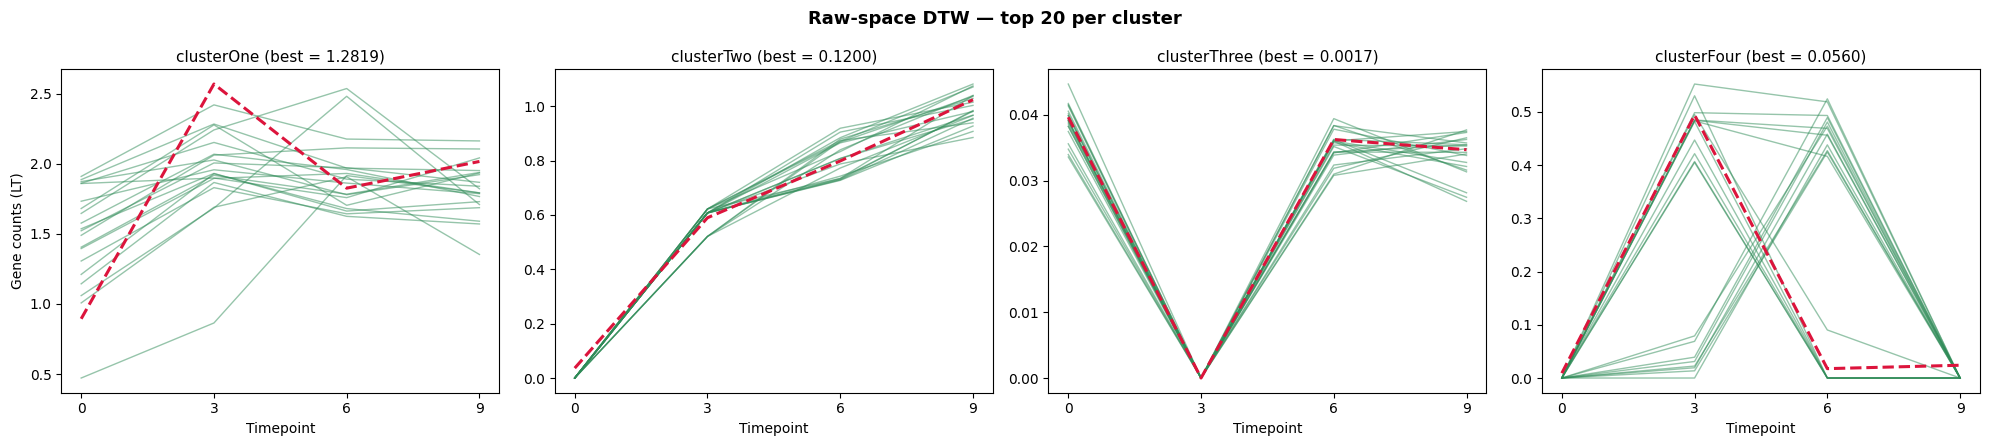

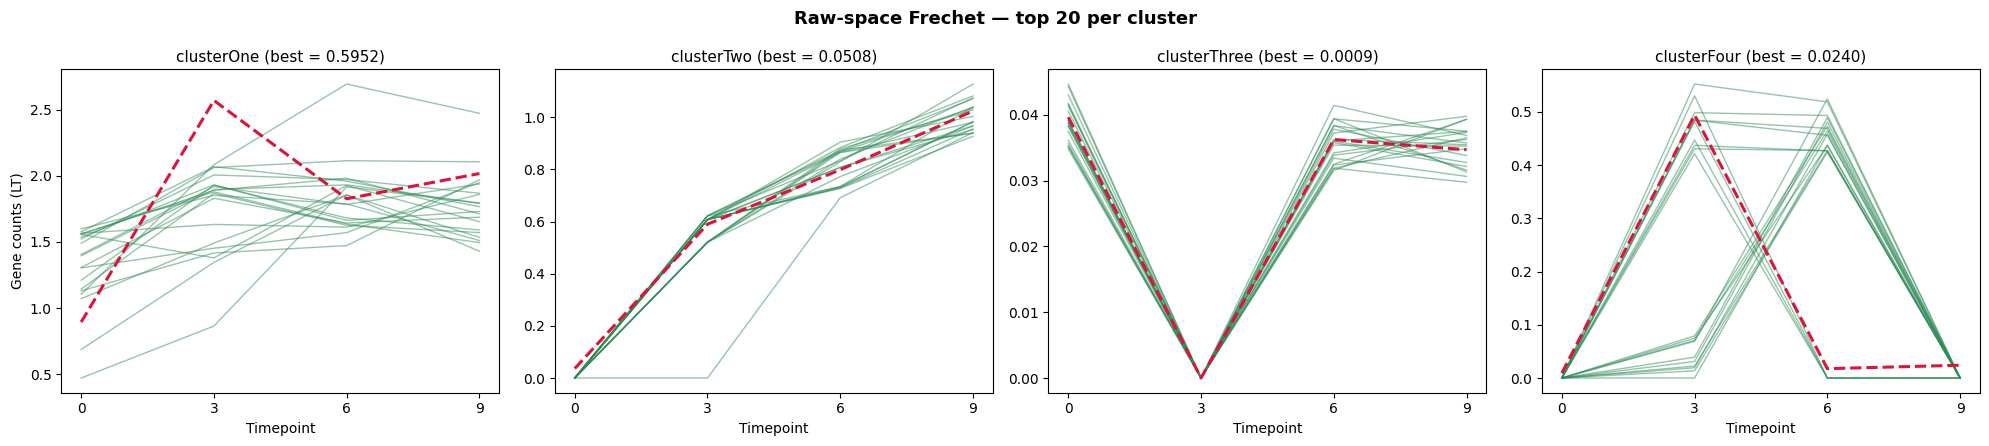

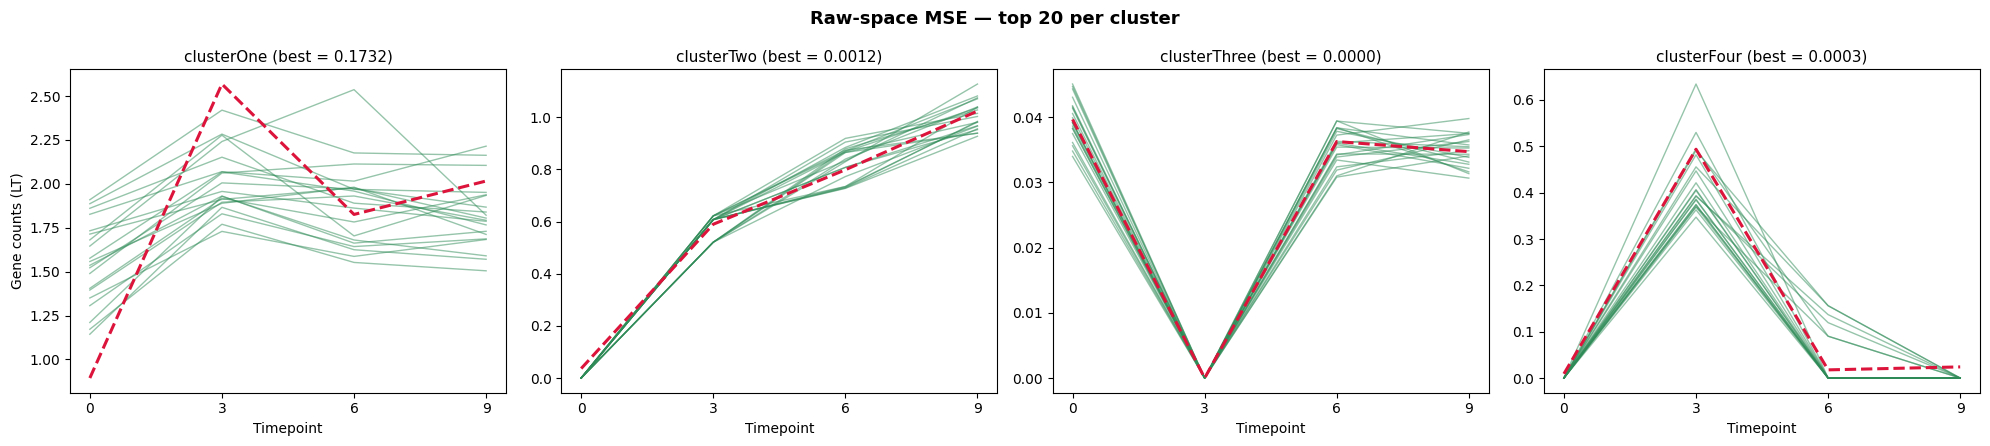

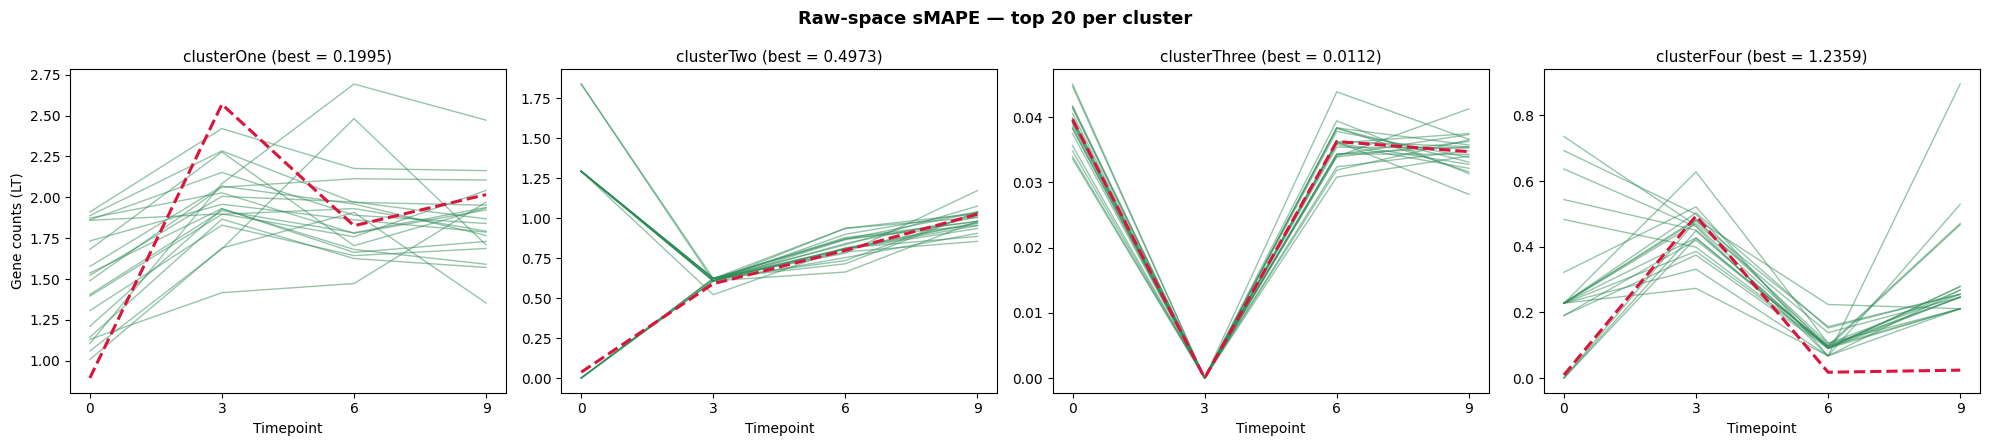

In [4]:
def plot_method_row(method_name, rankings, save_name):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
    for idx, cluster_name in enumerate(cluster_names):
        ax = axes[idx]
        gene_df = gene_dataLT[cluster_name]
        pattern_vals = constraint_patternsLT[cluster_name]['constraint']
        top20 = rankings[cluster_name].nsmallest(20)
        for gene in top20.index:
            if gene in gene_df.index:
                ax.plot(x, gene_df.loc[gene], color='seagreen', alpha=0.5, linewidth=1)
        ax.plot(x, pattern_vals, color='crimson', linewidth=2.2, linestyle='--')
        ax.set_xticks(x)
        ax.set_xlabel('Timepoint')
        if idx == 0:
            ax.set_ylabel('Gene counts (LT)')
        short = cluster_name.replace('LT', '')
        ax.set_title(f'{short} (best = {top20.iloc[0]:.4f})', fontsize=11)
    plt.suptitle(f'Raw-space {method_name} — top 20 per cluster', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_method_row('DTW',     raw_rankings['DTW'],     'raw_dtw')
plot_method_row('Frechet', raw_rankings['Frechet'], 'raw_frechet')
plot_method_row('MSE',     raw_rankings['MSE'],     'raw_mse')
plot_method_row('sMAPE',   raw_rankings['sMAPE'],   'raw_smape')

## Overlap with raw MAE

If DTW / Fréchet / MSE on raw data are genuinely magnitude-aware, their top-20 lists should overlap heavily with raw MAE's top-20 (all 4 are measuring some form of absolute-space distance). sMAPE should stand apart because it's structurally relative.

In [5]:
# Compute raw MAE for reference
raw_mae = {}
for cluster_name in cluster_names:
    pattern = np.array(constraint_patternsLT[cluster_name]['constraint'], dtype=float)
    gene_df = gene_dataLT[cluster_name]
    raw_mae[cluster_name] = pd.Series(np.mean(np.abs(gene_df.values - pattern), axis=1), index=gene_df.index)

print(f"{'Cluster':<14}{'DTW vs MAE':<14}{'Frechet vs MAE':<18}{'MSE vs MAE':<14}{'sMAPE vs MAE'}")
print('-' * 72)
for cluster_name in cluster_names:
    short = cluster_name.replace('LT', '')
    mae_top = set(raw_mae[cluster_name].nsmallest(20).index)
    dtw_top     = set(raw_rankings['DTW'][cluster_name].nsmallest(20).index)
    frechet_top = set(raw_rankings['Frechet'][cluster_name].nsmallest(20).index)
    mse_top     = set(raw_rankings['MSE'][cluster_name].nsmallest(20).index)
    smape_top   = set(raw_rankings['sMAPE'][cluster_name].nsmallest(20).index)
    print(f'{short:<14}{len(dtw_top & mae_top):>3}/20{"":<8}'
          f'{len(frechet_top & mae_top):>3}/20{"":<12}'
          f'{len(mse_top & mae_top):>3}/20{"":<8}'
          f'{len(smape_top & mae_top):>3}/20')

Cluster       DTW vs MAE    Frechet vs MAE    MSE vs MAE    sMAPE vs MAE
------------------------------------------------------------------------
clusterOne     17/20          9/20             14/20         17/20
clusterTwo     20/20         17/20             18/20          6/20
clusterThree   20/20         13/20             16/20         17/20
clusterFour     7/20          4/20             17/20          0/20


## Per-cluster composite — all 4 raw methods + raw MAE side by side

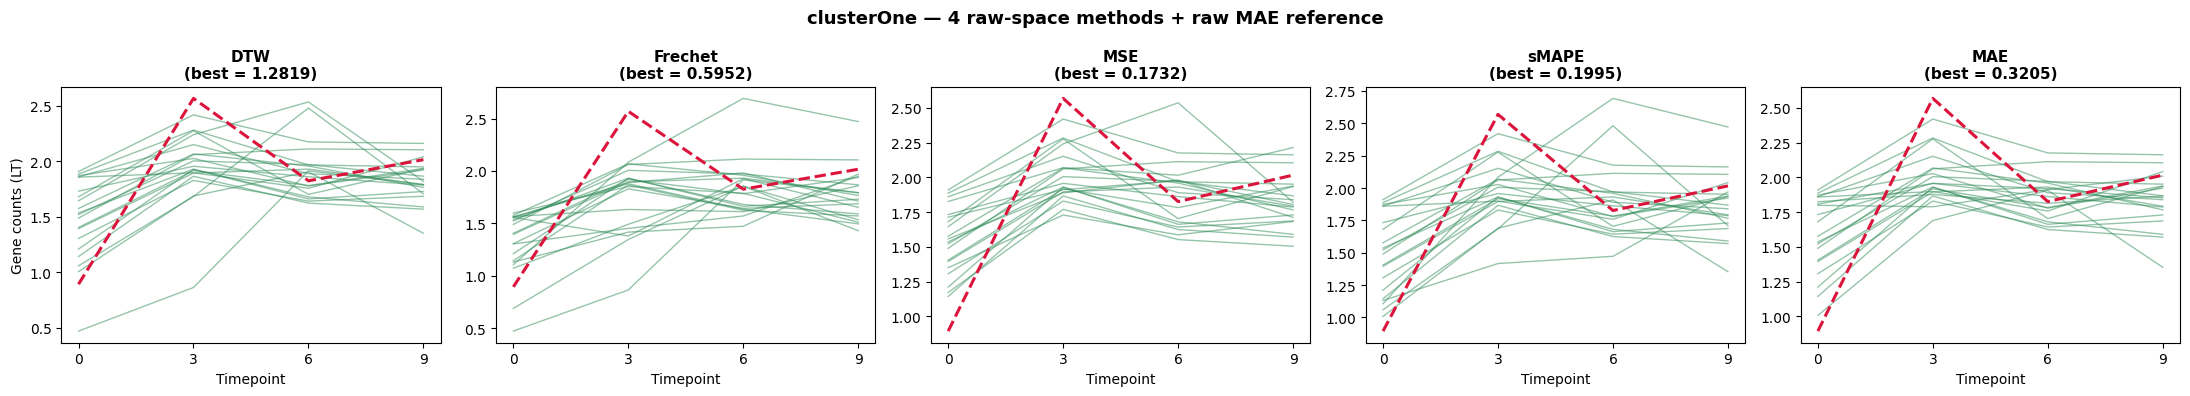

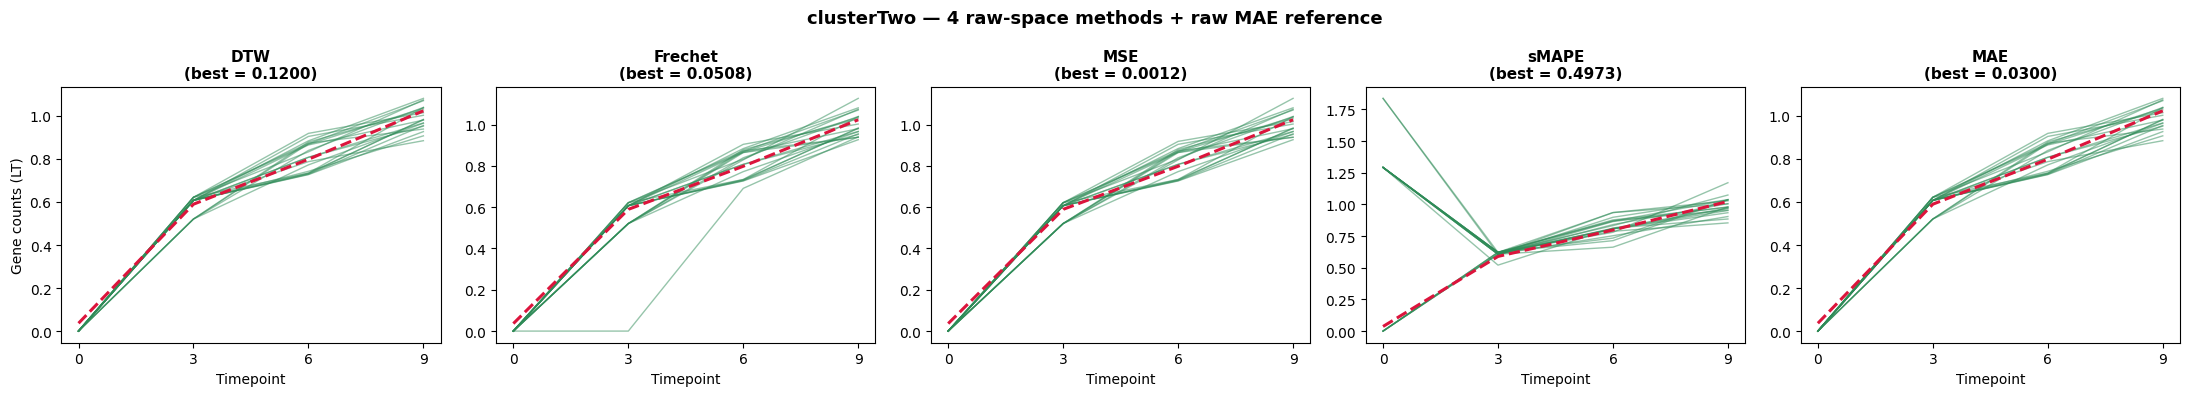

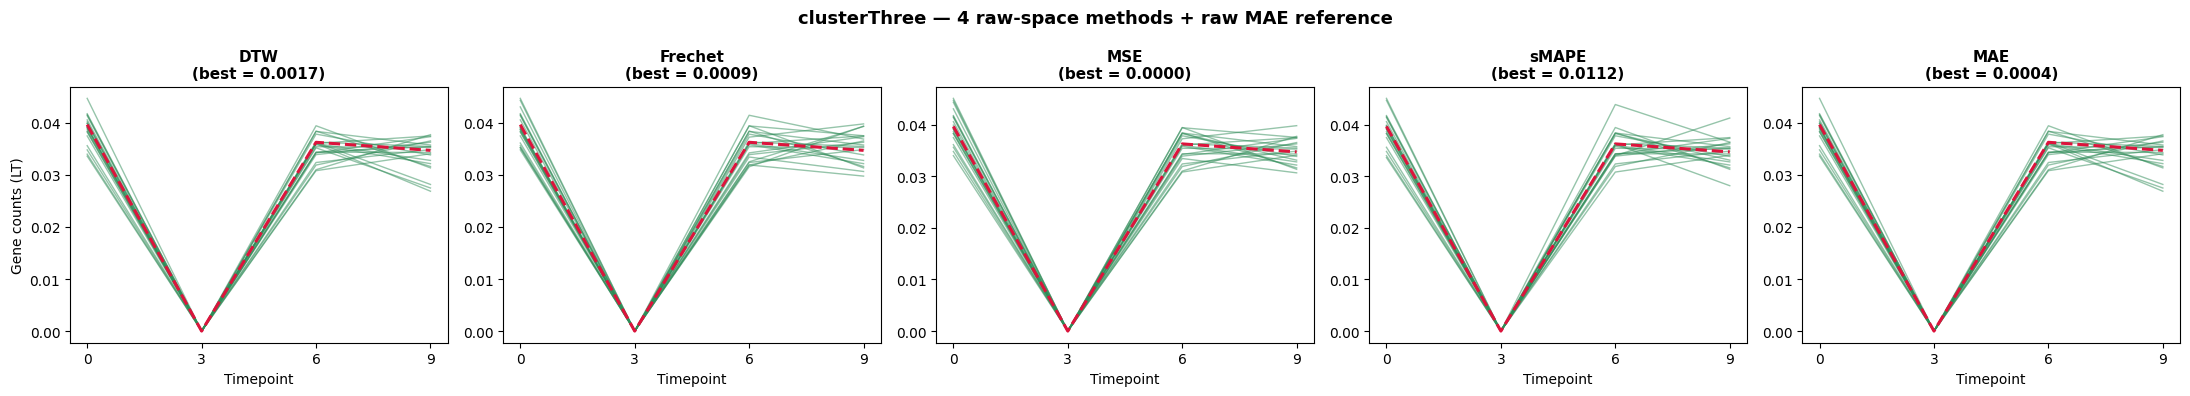

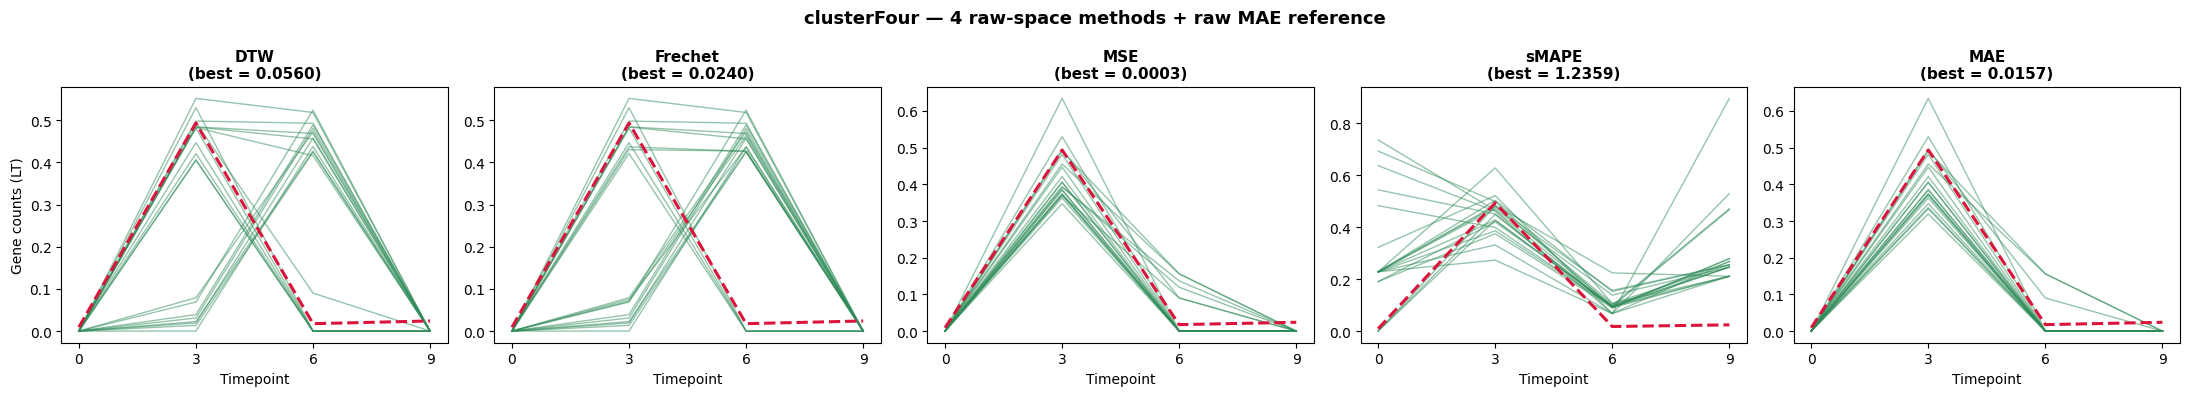

In [6]:
# 1x5 row per cluster: DTW, Fréchet, MSE, sMAPE, MAE — all on raw LT
method_series = [
    ('DTW',     raw_rankings['DTW']),
    ('Frechet', raw_rankings['Frechet']),
    ('MSE',     raw_rankings['MSE']),
    ('sMAPE',   raw_rankings['sMAPE']),
    ('MAE',     raw_mae),
]

for cluster_name in cluster_names:
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    gene_df = gene_dataLT[cluster_name]
    pattern_vals = constraint_patternsLT[cluster_name]['constraint']
    for ax, (method_name, rnk) in zip(axes, method_series):
        top20 = rnk[cluster_name].nsmallest(20)
        for gene in top20.index:
            if gene in gene_df.index:
                ax.plot(x, gene_df.loc[gene], color='seagreen', alpha=0.5, linewidth=1)
        ax.plot(x, pattern_vals, color='crimson', linewidth=2.2, linestyle='--')
        ax.set_xticks(x)
        ax.set_xlabel('Timepoint')
        ax.set_title(f'{method_name}\n(best = {top20.iloc[0]:.4f})', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Gene counts (LT)')
    short = cluster_name.replace('LT', '')
    plt.suptitle(f'{short} — 4 raw-space methods + raw MAE reference', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/raw_composite_{short}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Observations

Fill in after running — look at the overlap table and the composite plots and note:

1. **Do DTW / Fréchet / MSE converge on raw-MAE-like picks?** They should — all four are forms of absolute-space distance. MSE is literally a monotonic transform of MAE² (per-timepoint), so MSE and MAE rankings should be nearly identical. DTW and Fréchet allow some temporal slack / worst-case-focus but on 4 timepoints with equal spacing there's little room to differ from pointwise MAE.

2. **Does sMAPE stand apart?** sMAPE divides by $|g_t| + |p_t|$, so it's a percentage-like measure. Near-zero pattern values (e.g., clusterThree at $t=3$) make sMAPE behave erratically — a pattern timepoint of 0 combined with a gene value of 0 contributes 0 to the sum, but a gene value of any ε contributes 2 (since $2\varepsilon/\varepsilon = 2$). So sMAPE can give very different rankings even on raw data.

3. **Practical takeaway:** if the goal is magnitude-aware gene picking, raw MAE is essentially the cleanest / most interpretable version of this family. DTW and Fréchet add machinery (temporal warping, max-deviation focus) that doesn't buy much at n=4.